In [209]:
from llrf_app.app import LLRFApp
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import signal
from utils import calc_ps, plot_ps
import time

plt.rcParams['figure.figsize'] = [6, 4]
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.grid.which'] = "both"
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['font.size'] = 8

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Read Board Support info

In [210]:
slac_b15_ip = '192.168.19.171:803'
llrf = LLRFApp(addr=slac_b15_ip, conf='LEMP', chan_keep=7)
llrf.get_bsp_info()

Marble Variant: V1.4
ADN4600 U2:
  IN 2 -> OUT 0
  IN 3 -> OUT 1
  IN 2 -> OUT 2
  IN 3 -> OUT 3
INA219 U57, 12V:
  Vshunt     :     -5.8 mV
  Power      :     60.1 mW
  Vbus       :     11.9 V
  Current    :   -979.7 mA
INA219 U17, FMC1:
  Vshunt     :     22.6 mV
  Power      :     15.8 mW
  Vbus       :     11.8 V
  Current    :    327.7 mA
INA219 U32, FMC2:
  Vshunt     :      1.0 mV
  Power      :     14.4 mW
  Vbus       :     11.9 V
  Current    :      1.1 mA
 PCA9555 U34, QSFP:
  I0         :    01111111
  I1         :    01001111
 PCA9555 U39, MISC:
  I0         :    11111110
  I1         :    11110011
QSFP 2 is present:
  Vendor     :    Fiberstore      
  Part       :    QSFP-SR4-40G    
  Serial     :    G1804130284     
  TXRX_LOS   :    11111101
  Temp       :    36 C
  Volt       :    3180 mV
  TxBias0    :    5726 uA
  TxPwr0     :    1002 uW
  RxPwr0     :    0 uW
  TxBias1    :    5680 uA
  TxPwr1     :    994 uW
  RxPwr1     :    163 uW
  TxBias2    :    5640 uA
  Tx

Measure a snapshot of RF amplitude and phases

In [211]:
llrf.reg_write([
    ('amp_setpoint', 12000),
    ('phs_setpoint', 0),
    ('inlk_permit_mask', 0),
    ('dac_permit', 1),
    ('pulse_mode', 0)
])
time.sleep(0.1)

raw_wfms = llrf.read_raw_bufs()
adc_wfm = raw_wfms[:8]
dac_wfm = raw_wfms[8:10]

In [212]:
df_mon = llrf.get_rfmon()
df_mon

,mon_amp,mon_phs,Amp [cnt],Phs [deg]
adc0,15678,-43427,26303.559654,-119.275818
adc1,17307,-7119,29036.593120,-19.552917
adc2,6308,18192,10583.164581,49.965820
adc3,585,60,981.476107,0.164795
adc4,13701,44961,22986.673736,123.489075
adc5,546,41678,916.044366,114.472046
adc6,5,-65389,8.388685,-179.596252
adc7,42,-49138,70.464951,-134.961548
dac0,2768,0,4643.975834,0.000000
dac1,2768,0,4643.975834,0.000000


Confirm MO phase is aligned

In [213]:
mo_adc_chan = llrf.read_reg('mo_adc_chan')
fdbk_adc_chan = llrf.read_reg('fdbk_adc_chan')
mo_adc = f'adc{mo_adc_chan}'
fdbk_adc = f'adc{fdbk_adc_chan}'
print(f'MO ADC = {mo_adc}, FDBK ADC = {fdbk_adc}')

MO ADC = adc3, FDBK ADC = adc0


In [214]:
assert -0.2 < df_mon['Phs [deg]'][mo_adc] < 0.2

## Plot raw DAC / ADC data

In [215]:
df_sig = llrf.get_raw_bufs_df() 

<AxesSubplot:xlabel='Time [ns]'>

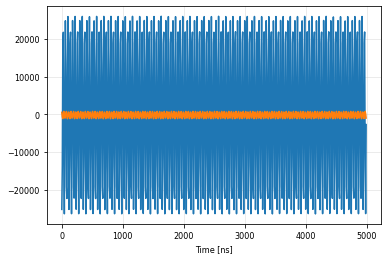

In [216]:
df_sig[fdbk_adc].loc[:5000].plot()
df_sig[mo_adc].loc[:5000].plot()

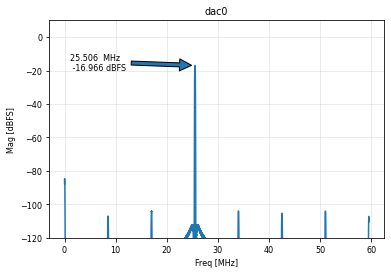

In [217]:
f, psd_dbfs = calc_ps(df_sig['dac0'], fs_mhz=1e3/llrf.DSP_CLK_CYCLE)
plot_ps(f, psd_dbfs, title='dac0', annotate=True)

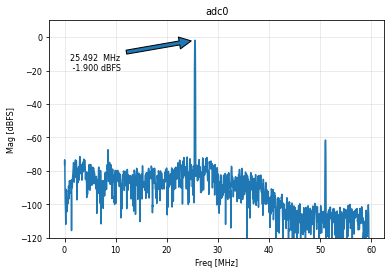

In [218]:
f, psd_dbfs = calc_ps(df_sig[fdbk_adc], fs_mhz=1e3/llrf.DSP_CLK_CYCLE)
plot_ps(f, psd_dbfs, title=fdbk_adc, annotate=True)

# Pulse mode test

In [219]:
# generate 4µs pulse
pulse_high_len = int(4000 / llrf.DSP_CLK_CYCLE  / llrf.CIC_BASE_PERIOD)
llrf.reg_write([
    ('amp_setpoint', 12000),
    ('pulse_high_len', pulse_high_len),
    ('pulse_mode', 1)
])
time.sleep(0.5)

print(f'pulse_high_len: {pulse_high_len} counts')

pulse_high_len: 16 counts


<AxesSubplot:xlabel='Time [ns]'>

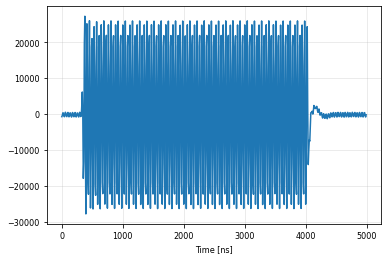

In [221]:
df_sig = llrf.get_raw_bufs_df()
df_sig['adc0'].loc[:5000].plot()

In [224]:
df_iq = llrf.get_iq_wfms_df() 

<AxesSubplot:xlabel='Time [ns]'>

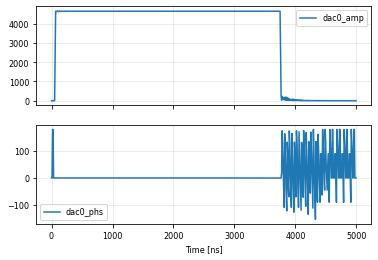

In [225]:
len_ns = 5000
fig, axes = plt.subplots(2, sharex=True)
df_iq[['dac0' + '_amp']].loc[:len_ns].plot(ax=axes[0])
df_iq[['dac0' + '_phs']].loc[:len_ns].plot(ax=axes[1])

<AxesSubplot:xlabel='Time [ns]'>

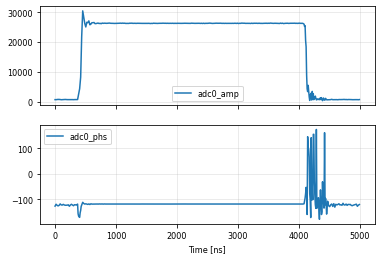

In [226]:
fig, axes = plt.subplots(2, sharex=True)
df_iq[[fdbk_adc + '_amp']].loc[:len_ns].plot(ax=axes[0])
df_iq[[fdbk_adc + '_phs']].loc[:len_ns].plot(ax=axes[1])

Verify IQ waveform signal gain:

In [227]:

amp = df_iq[[fdbk_adc + '_amp']].loc[500:4000].values.mean()
phs = df_iq[[fdbk_adc + '_phs']].loc[500:4000].values.mean()
print(f'fdbk_adc IQ waveform signal: amp = {amp:8.3f} cnt, phs = {phs:8.3f} deg')

amp_exp = df_mon['Amp [cnt]'][fdbk_adc]
phs_exp = df_mon['Phs [deg]'][fdbk_adc]
print(f'fdbk_adc expected inlk_mon:  amp = {amp_exp:8.3f} cnt, '
      f'phs = {phs_exp:8.3f} deg')

fdbk_adc IQ waveform signal: amp = 26323.691 cnt, phs = -119.128 deg
fdbk_adc expected inlk_mon:  amp = 26303.560 cnt, phs = -119.276 deg


## Plot circular buffer data

In [228]:
df_mp = llrf.get_cic_wfm_df()

<AxesSubplot:title={'center':'ADC0 Phase'}, xlabel='Time [ns]'>

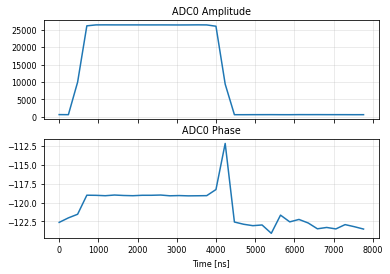

In [229]:
fig, axes = plt.subplots(2, sharex=True)
df_mp[fdbk_adc + '_amp'].loc[:8000].plot(title='ADC0 Amplitude', ax=axes[0])
df_mp[fdbk_adc + '_phs'].loc[:8000].plot(title='ADC0 Phase', ax=axes[1])